# Customer Churn Prediction

The Customer Churn table contains information on all 7,043 customers from a Telecommunications company in California in Q2 2022


Each record represents one customer, and contains details about their demographics, location, tenure, subscription services, status for the quarter (joined, stayed, or churned), and more!

The Zip Code Population table contains complimentary information on the estimated populations for the California zip codes in the Customer Churn table

Importing necessary files

In [170]:
import numpy as np
import pandas as pd

In [201]:
df=pd.read_csv('telecom_customer_churn.csv')

In [202]:
df.head(5)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


Overviewing all the columns in the dataset

In [203]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='str')

In [204]:
df.shape

(7043, 38)

In [205]:
df1 = df.copy()

Creating a copy of the Dataset

In [206]:
df1.head(7)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,Credit Card,69.4,571.45,0.00,0,150.93,722.38,Stayed,NaN,NaN
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,...,Bank Withdrawal,109.7,7904.25,0.00,0,707.16,8611.41,Stayed,NaN,NaN


In [207]:
df1.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='str')

In [208]:
df1.shape

(7043, 38)

# Exploratory Data Analysis

# Data Preprocessing

Dropping unwanted columns from the dataset

### Justification for Dropping Columns
- **Customer ID**: Unique identifier with no predictive power.
- **Total Refunds**: Highly correlated with revenue metrics and often unknown at the time of prediction.
- **Zip Code, Latitude, Longitude**: Geospatial features that are complex to model; the 'City' feature provides sufficient geographical context for this baseline.
- **Churn Category, Churn Reason**: These are 'target leakage' features. They are only known *after* a customer has already churned, making them useless for predicting future churn.

In [209]:
df1.drop(['Customer ID','Total Refunds','Zip Code','Latitude', 'Longitude','Churn Category', 'Churn Reason'],axis='columns',inplace=True)


In [210]:
df1.shape

(7043, 31)

In [211]:
df1.dtypes

Gender                                   str
Age                                    int64
Married                                  str
Number of Dependents                   int64
City                                     str
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                    str
Phone Service                            str
Avg Monthly Long Distance Charges    float64
Multiple Lines                           str
Internet Service                         str
Internet Type                            str
Avg Monthly GB Download              float64
Online Security                          str
Online Backup                            str
Device Protection Plan                   str
Premium Tech Support                     str
Streaming TV                             str
Streaming Movies                         str
Streaming Music                          str
Unlimited Data                           str
Contract  

Checking the number of unique values in each column

In [212]:
features = df1.columns
for feature in features:
     print(f'{feature}--->{df[feature].nunique()}')

Gender--->2
Age--->62
Married--->2
Number of Dependents--->10
City--->1106
Number of Referrals--->12
Tenure in Months--->72
Offer--->5
Phone Service--->2
Avg Monthly Long Distance Charges--->3583
Multiple Lines--->2
Internet Service--->2
Internet Type--->3
Avg Monthly GB Download--->49
Online Security--->2
Online Backup--->2
Device Protection Plan--->2
Premium Tech Support--->2
Streaming TV--->2
Streaming Movies--->2
Streaming Music--->2
Unlimited Data--->2
Contract--->3
Paperless Billing--->2
Payment Method--->3
Monthly Charge--->1591
Total Charges--->6540
Total Extra Data Charges--->16
Total Long Distance Charges--->6068
Total Revenue--->6975
Customer Status--->3


Getting the percentge of Null Values in each Column

In [213]:
df1.isnull().sum() / df1.shape[0]

Gender                               0.000000
Age                                  0.000000
Married                              0.000000
Number of Dependents                 0.000000
City                                 0.000000
Number of Referrals                  0.000000
Tenure in Months                     0.000000
Offer                                0.550476
Phone Service                        0.000000
Avg Monthly Long Distance Charges    0.096834
Multiple Lines                       0.096834
Internet Service                     0.000000
Internet Type                        0.216669
Avg Monthly GB Download              0.216669
Online Security                      0.216669
Online Backup                        0.216669
Device Protection Plan               0.216669
Premium Tech Support                 0.216669
Streaming TV                         0.216669
Streaming Movies                     0.216669
Streaming Music                      0.216669
Unlimited Data                    

Cleaning Function for the Dataset

In [214]:
def clean_dataset(df):
    assert isinstance(df, pd.DataFrame)
    df.dropna(inplace=True)
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(1)
    return df[indices_to_keep].astype(np.float64)

### Handling Missing Values (Imputation Strategy)
Instead of dropping nearly 21.7% of our records, we use **imputation** to preserve data volume:
- **Numerical Columns**: Imputed with the **median** to handle potential outliers.
- **Categorical Columns**: Imputed with the **mode** (most frequent value).

In [215]:
# Fill categorical columns with mode
for col in df1.select_dtypes(include=['object', 'string', 'category']).columns:
    df1[col] = df1[col].fillna(df1[col].mode()[0])

# Fill numeric columns with median
for col in df1.select_dtypes(include=['number']).columns:
    df1[col] = df1[col].fillna(df1[col].median())

print("Missing values after imputation:", df1.isnull().sum().sum())

Missing values after imputation: 0


## Feature Engineering
We create new features to capture more complex relationships:
1. **Service_Diversity**: A count of how many additional services a customer uses. Higher diversity often correlates with higher 'stickiness'.
2. **Monthly_Revenue_Per_Tenure**: Captures the intensity of spending relative to customer age.

In [216]:
# 1. Service Diversity: Summing up all binary service columns
services = ['Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup', 
            'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 
            'Streaming Movies', 'Streaming Music']

df1['Service_Diversity'] = df1[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

# 2. Monthly Revenue Per Tenure
df1['Avg_Revenue_Per_Tenure'] = df1['Total Revenue'] / (df1['Tenure in Months'] + 1)

df1[['Service_Diversity', 'Avg_Revenue_Per_Tenure']].head()

,Service_Diversity,Avg_Revenue_Per_Tenure
0,4,97.481000
1,4,61.028000
2,2,83.090000
3,5,114.250714
4,3,72.385000


In [217]:
df['Unlimited Data'] 

0       Yes
1        No
2       Yes
3       Yes
4       Yes
       ... 
7038    Yes
7039    Yes
7040    Yes
7041    Yes
7042    Yes
Name: Unlimited Data, Length: 7043, dtype: str

In [218]:
number_columns=['Age','Number of Dependents','Number of Referrals','Tenure in Months','Avg Monthly Long Distance Charges','Avg Monthly GB Download','Monthly Charge','Total Charges','Total Extra Data Charges','Total Long Distance Charges','Total Revenue']

Checking the unique values of column having datatype: 'object'

In [219]:
def unique_values_names(df):
    for column in df:
        if df[column].dtype=='object':
            print(f'{column}:{df[column].unique()}')

In [220]:
unique_values_names(df1)

# Data Visualization

Visualizing Column 'Age' in the dataset

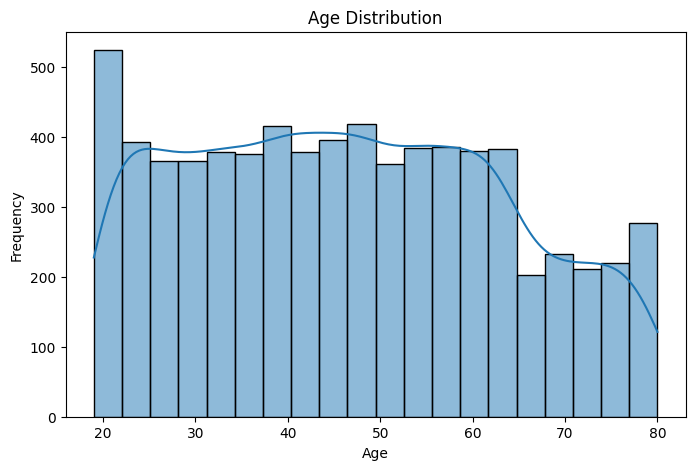

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Checking the stats in number_columns of the copied dataset

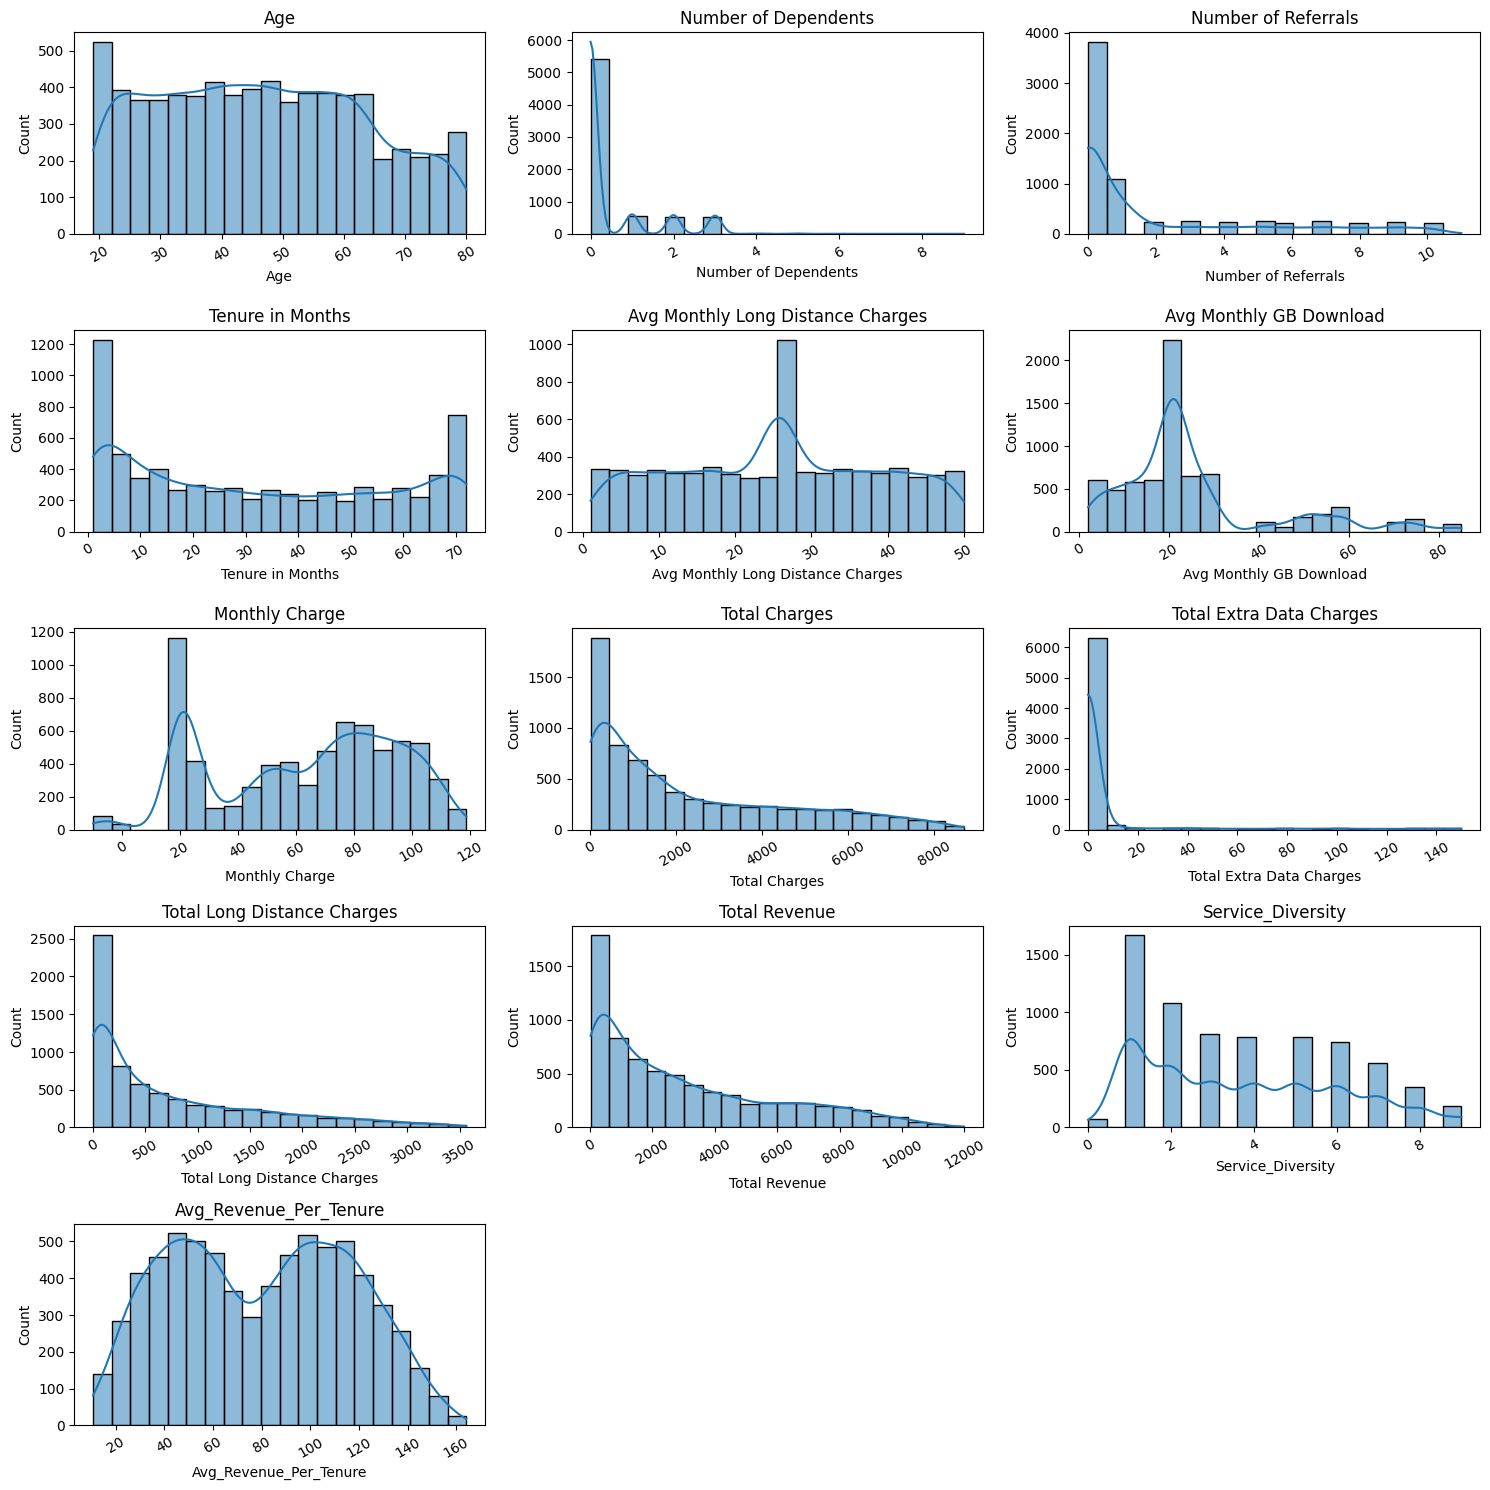

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df1.select_dtypes(include=['number']).columns

# Create subplots grid
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 15))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df1[col], bins=20, kde=True)
    plt.title(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [223]:
df1['Age']


0       37
1       46
2       50
3       78
4       75
        ..
7038    20
7039    40
7040    22
7041    21
7042    36
Name: Age, Length: 7043, dtype: int64

In [224]:
import matplotlib.pyplot as plt

Visualizing the number of customers who churned, stayed or joined in the company with a bar plot

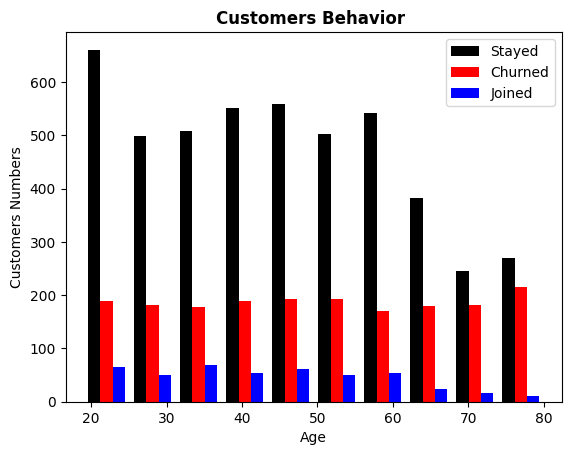

In [225]:
Customer_Stayed=df1[df1['Customer Status']=='Stayed'].Age
Customer_Churned=df1[df1['Customer Status']=='Churned'].Age
Customer_Joined=df1[df1['Customer Status']=='Joined'].Age

plt.xlabel('Age')
plt.ylabel('Customers Numbers')
plt.hist([Customer_Stayed,Customer_Churned,Customer_Joined], color=['black','red','blue'],label=['Stayed','Churned','Joined'])

plt.title('Customers Behavior ',fontweight ="bold")
plt.legend()

In [226]:
import seaborn as sns

 # Defining Correlation between the columns in the dataset

In [227]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   str    
 1   Age                                7043 non-null   int64  
 2   Married                            7043 non-null   str    
 3   Number of Dependents               7043 non-null   int64  
 4   City                               7043 non-null   str    
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Offer                              7043 non-null   str    
 8   Phone Service                      7043 non-null   str    
 9   Avg Monthly Long Distance Charges  7043 non-null   float64
 10  Multiple Lines                     7043 non-null   str    
 11  Internet Service                   7043 non-null   str    
 12  Int

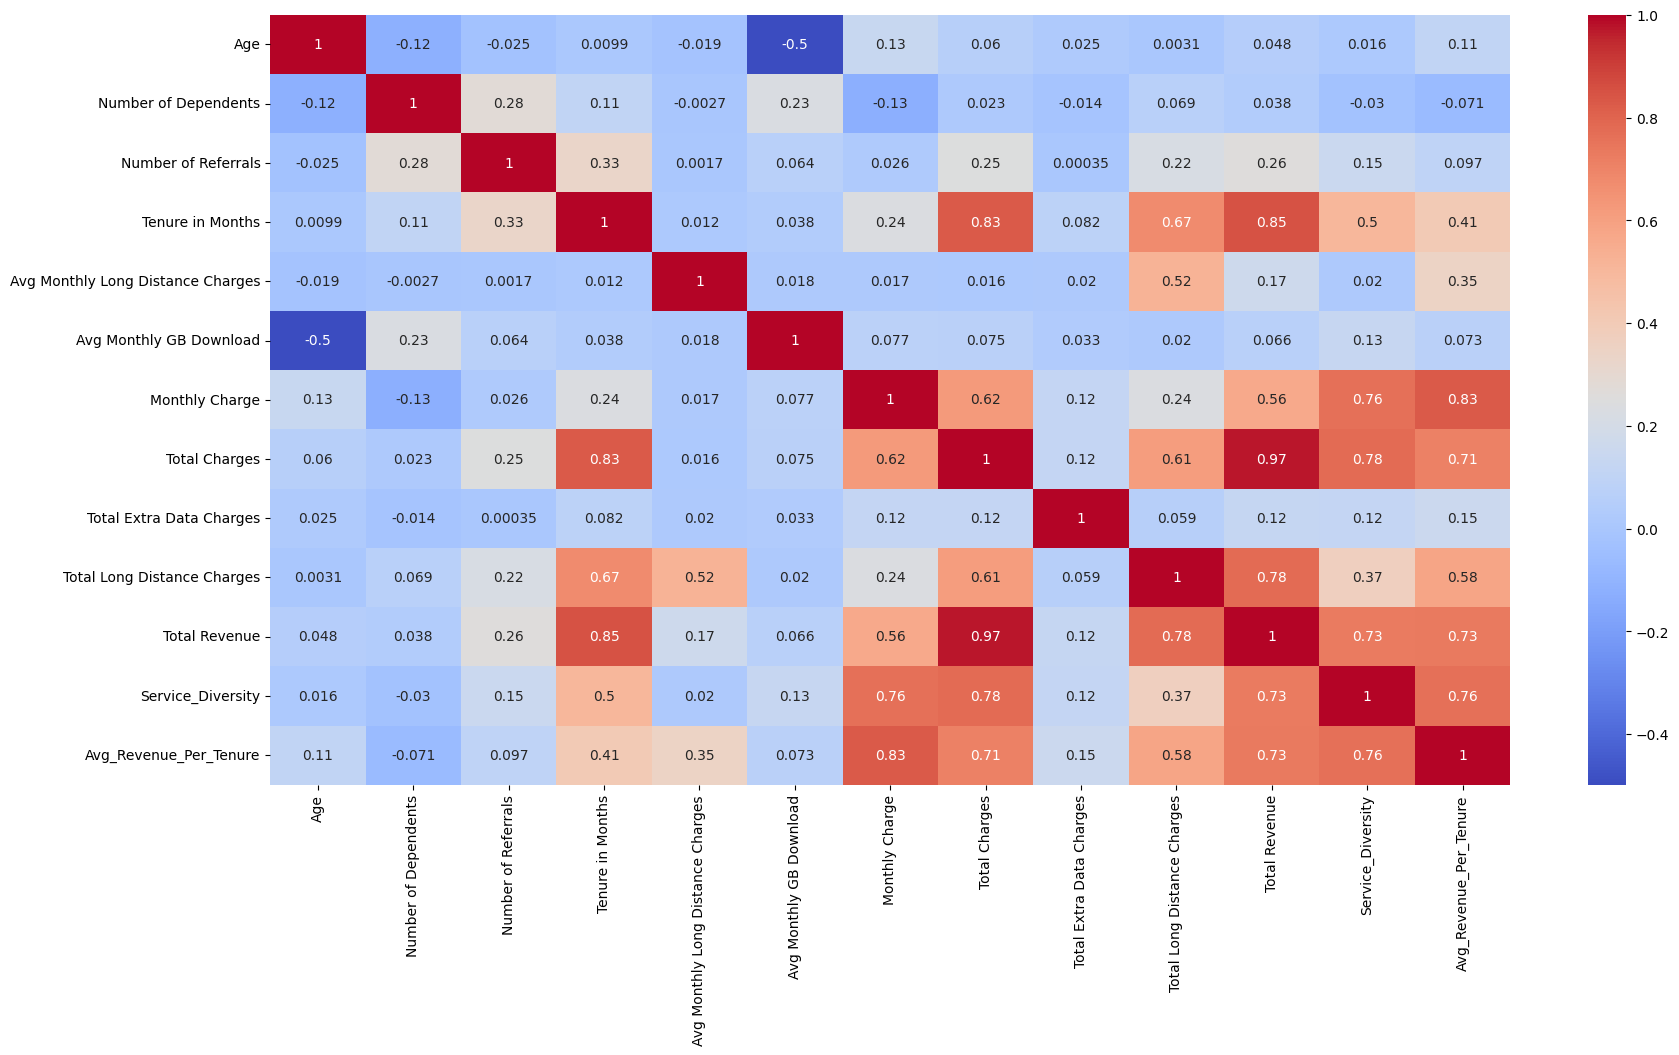

In [228]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df1.select_dtypes(include=['int64', 'float64'])

# Compute correlation
data = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(20,10))
sns.heatmap(data, annot=True, cmap='coolwarm')
plt.show()

Analyzing Outlier in the dataset with respect to customer status

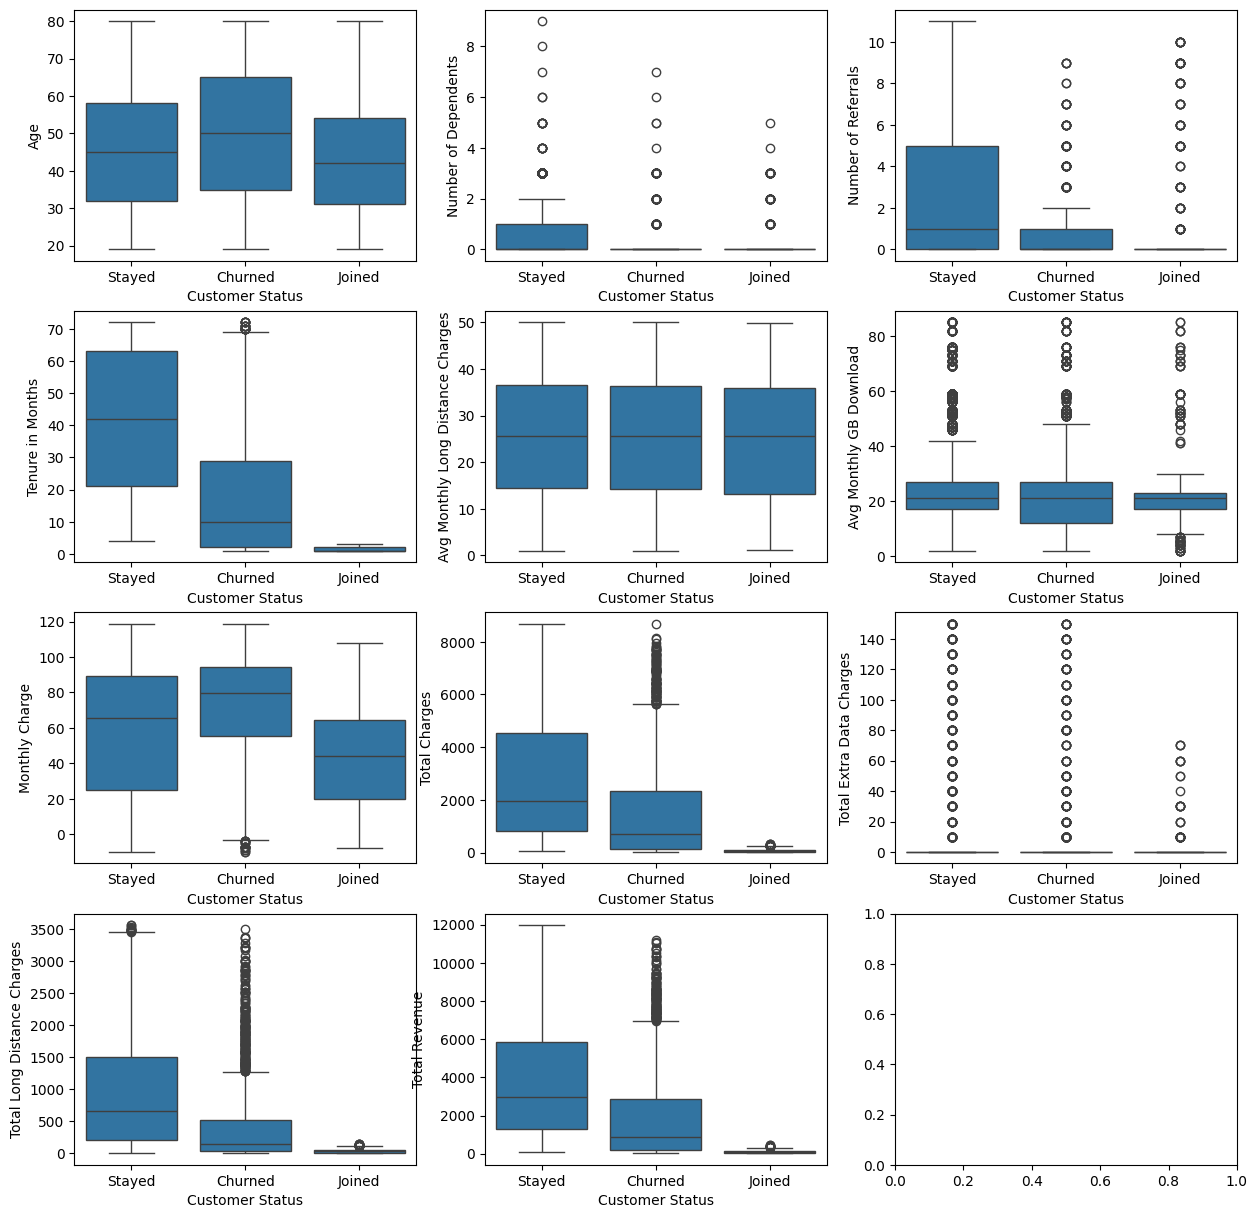

In [229]:
fig, ax = plt.subplots(4,3, figsize = (15,15))
for i, subplot in zip(number_columns, ax.flatten()):
    sns.boxplot(x = 'Customer Status', y = i , data = df1, ax = subplot)

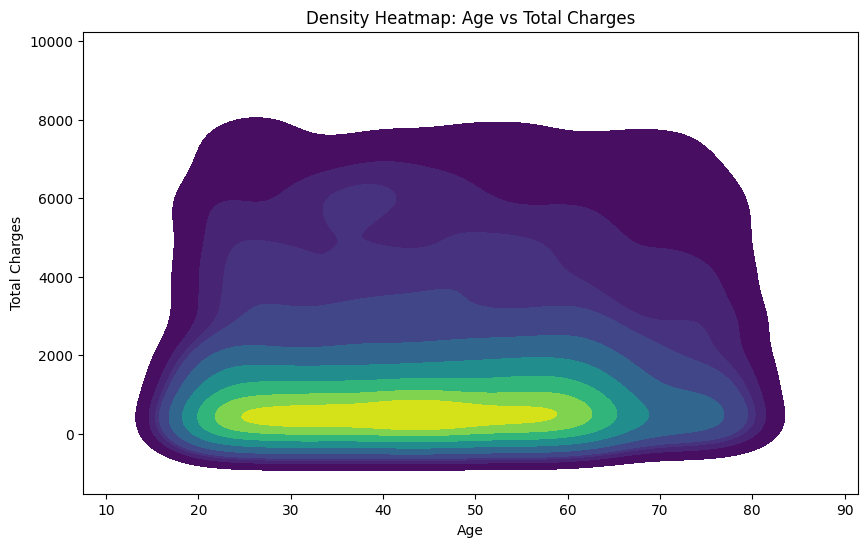

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df1,
    x="Age",
    y="Total Charges",
    fill=True,        
    cmap="viridis",
    thresh=0.05
)

plt.title("Density Heatmap: Age vs Total Charges")
plt.show()

In [231]:
df1.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'City',
       'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Service_Diversity',
       'Avg_Revenue_Per_Tenure'],
      dtype='str')

<Axes: xlabel='Customer Status'>

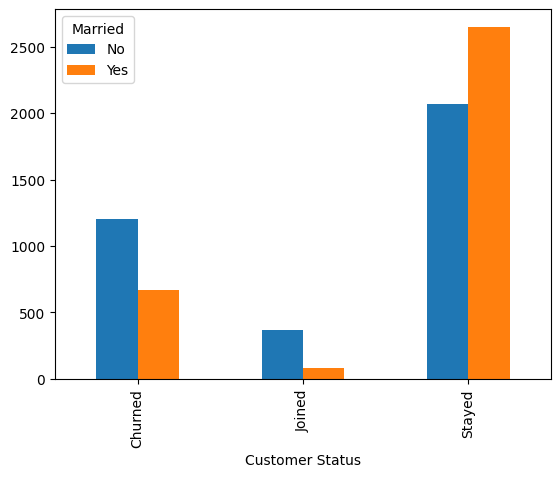

In [232]:
pd.crosstab(df['Customer Status'], df['Married']).plot(kind='bar')

<Axes: xlabel='Customer Status'>

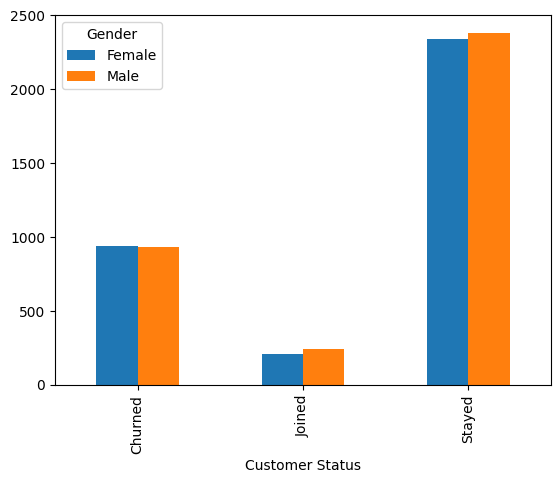

In [233]:
pd.crosstab(df['Customer Status'], df['Gender']).plot(kind='bar')

In [234]:
df1['Payment Method'].unique()

<StringArray>
['Credit Card', 'Bank Withdrawal', 'Mailed Check']
Length: 3, dtype: str

Create dictionary with role / data key value pairs

In [235]:
Roles = {}
for j in df1['Payment Method'].unique():
    Roles[j] = df1[df1['Payment Method'] == j]

In [236]:
Roles.keys()

dict_keys(['Credit Card', 'Bank Withdrawal', 'Mailed Check'])

Selecting the rows where the role is 'Credit Card'

In [237]:
Roles['Credit Card']

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Service_Diversity,Avg_Revenue_Per_Tenure
0,Female,37,Yes,0,Frazier Park,2,9,Offer B,Yes,42.39,...,Yes,Credit Card,65.60,593.30,0,381.51,974.81,Stayed,4,97.481000
1,Male,46,No,0,Glendale,0,9,Offer B,Yes,10.69,...,No,Credit Card,-4.00,542.40,10,96.21,610.28,Stayed,4,61.028000
4,Female,75,Yes,0,Camarillo,3,3,Offer B,Yes,7.38,...,Yes,Credit Card,83.90,267.40,0,22.14,289.54,Churned,3,72.385000
5,Female,23,No,3,Midpines,0,9,Offer E,Yes,16.77,...,Yes,Credit Card,69.40,571.45,0,150.93,722.38,Stayed,5,72.238000
7,Male,52,Yes,0,Napa,8,63,Offer B,Yes,12.96,...,Yes,Credit Card,84.65,5377.80,20,816.48,6214.28,Stayed,4,97.098125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,Female,20,No,0,Los Angeles,0,7,Offer E,Yes,36.49,...,Yes,Credit Card,94.05,633.45,0,255.43,888.88,Stayed,5,111.110000
7036,Female,53,No,0,Hume,0,1,Offer E,Yes,42.09,...,Yes,Credit Card,70.15,70.15,0,42.09,112.24,Churned,1,56.120000
7038,Female,20,No,0,La Mesa,0,13,Offer D,Yes,46.68,...,No,Credit Card,55.15,742.90,0,606.84,1349.74,Stayed,4,96.410000
7040,Male,22,No,0,Elk,0,2,Offer E,Yes,18.62,...,Yes,Credit Card,50.30,92.75,0,37.24,129.99,Joined,2,43.330000


In [238]:
len(Roles)


3

Checking the number of Offers in the dataset

In [239]:
off = df1['Offer'].value_counts()
off


Offer
Offer B    4701
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

In [240]:
import plotly.graph_objects as go

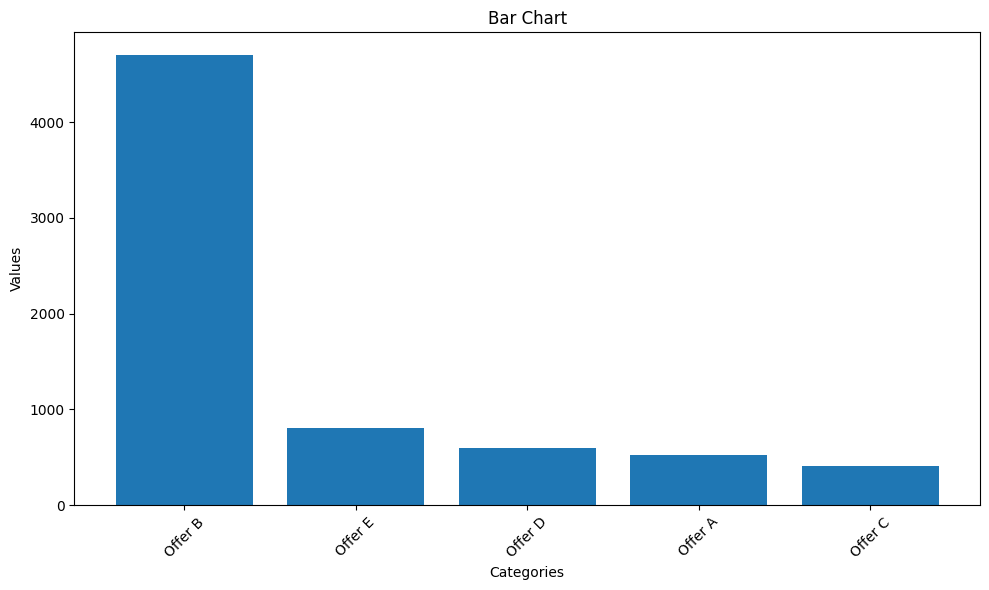

In [241]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(off.index, off.values)

plt.xlabel("Categories")
plt.ylabel("Values")
plt.title("Bar Chart")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [242]:
df1_off = Roles['Credit Card'].Offer.value_counts()
df1_off

Offer
Offer B    1828
Offer E     267
Offer D     251
Offer A     239
Offer C     164
Name: count, dtype: int64

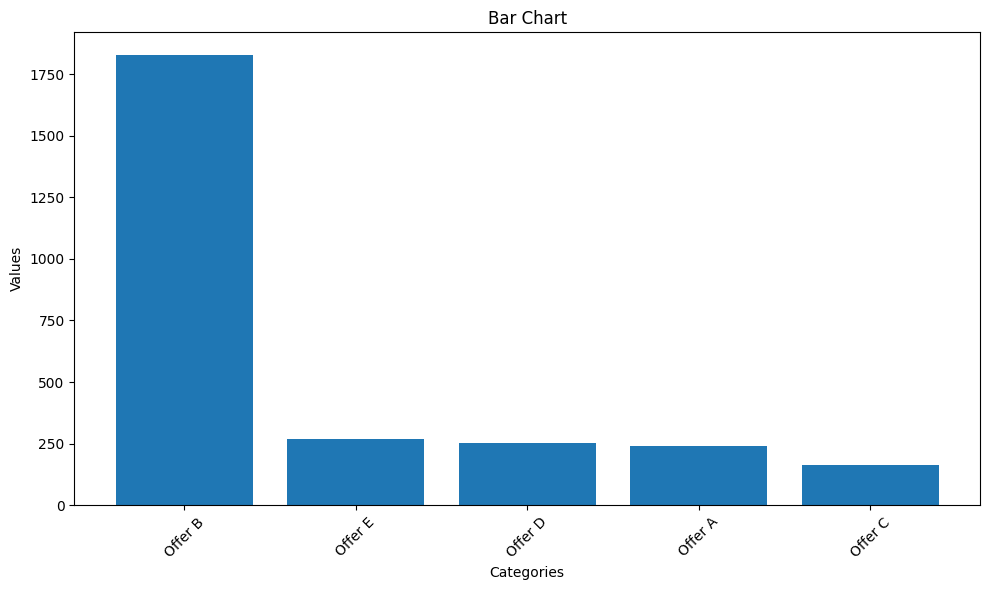

In [243]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(df1_off.index, df1_off.values)

plt.xlabel("Categories")
plt.ylabel("Values")
plt.title("Bar Chart")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [244]:
df1 = df1.rename(columns = {'Customer Status':'Customer_Status'})

In [245]:
Roles1 = {}
for k in df1['Customer_Status'].unique():
    Roles1[k] = df1[df1['Customer_Status'] == k]
Roles1.keys()

dict_keys(['Stayed', 'Churned', 'Joined'])

In [246]:
df1_state = Roles1['Stayed'].Offer.value_counts()
df1_state

Offer
Offer B    3270
Offer A     485
Offer D     441
Offer C     320
Offer E     204
Name: count, dtype: int64

# Data Modelling

Replacing the Gender column in the dataset with Label Encoding

0 for Female

1 for Male

In [247]:
df1.replace({"Gender":{'Female':0,'Male':1}},inplace=True)

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer_Status,Service_Diversity,Avg_Revenue_Per_Tenure
0,0,37,Yes,0,Frazier Park,2,9,Offer B,Yes,42.39,...,Yes,Credit Card,65.60,593.30,0,381.51,974.81,Stayed,4,97.481000
1,1,46,No,0,Glendale,0,9,Offer B,Yes,10.69,...,No,Credit Card,-4.00,542.40,10,96.21,610.28,Stayed,4,61.028000
2,1,50,No,0,Costa Mesa,0,4,Offer E,Yes,33.65,...,Yes,Bank Withdrawal,73.90,280.85,0,134.60,415.45,Churned,2,83.090000
3,1,78,Yes,0,Martinez,1,13,Offer D,Yes,27.82,...,Yes,Bank Withdrawal,98.00,1237.85,0,361.66,1599.51,Churned,5,114.250714
4,0,75,Yes,0,Camarillo,3,3,Offer B,Yes,7.38,...,Yes,Credit Card,83.90,267.40,0,22.14,289.54,Churned,3,72.385000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,20,No,0,La Mesa,0,13,Offer D,Yes,46.68,...,No,Credit Card,55.15,742.90,0,606.84,1349.74,Stayed,4,96.410000
7039,1,40,Yes,0,Riverbank,1,22,Offer D,Yes,16.20,...,Yes,Bank Withdrawal,85.10,1873.70,0,356.40,2230.10,Churned,4,96.960870
7040,1,22,No,0,Elk,0,2,Offer E,Yes,18.62,...,Yes,Credit Card,50.30,92.75,0,37.24,129.99,Joined,2,43.330000
7041,1,21,Yes,0,Solana Beach,5,67,Offer A,Yes,2.12,...,No,Credit Card,67.85,4627.65,0,142.04,4769.69,Stayed,6,70.142500


Replacing the columns with 'yes' and 'no' output by Label Encoding

0 for No

1 for Yes

In [248]:
yes_and_no=[  'Paperless Billing', 'Unlimited Data', 
       'Streaming Movies', 'Streaming Music',  'Streaming TV',
       'Premium Tech Support', 'Device Protection Plan', 'Online Backup', 'Online Security',
       'Multiple Lines',  'Married']
for i in yes_and_no:
    df1.replace({'No':0,'Yes':1},inplace=True)

Replacing 'Phone Service' with '1'

In [249]:
df1.replace({"Phone Service":{'Yes':1}},inplace=True)

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer_Status,Service_Diversity,Avg_Revenue_Per_Tenure
0,0,37,1,0,Frazier Park,2,9,Offer B,1,42.39,...,1,Credit Card,65.60,593.30,0,381.51,974.81,Stayed,4,97.481000
1,1,46,0,0,Glendale,0,9,Offer B,1,10.69,...,0,Credit Card,-4.00,542.40,10,96.21,610.28,Stayed,4,61.028000
2,1,50,0,0,Costa Mesa,0,4,Offer E,1,33.65,...,1,Bank Withdrawal,73.90,280.85,0,134.60,415.45,Churned,2,83.090000
3,1,78,1,0,Martinez,1,13,Offer D,1,27.82,...,1,Bank Withdrawal,98.00,1237.85,0,361.66,1599.51,Churned,5,114.250714
4,0,75,1,0,Camarillo,3,3,Offer B,1,7.38,...,1,Credit Card,83.90,267.40,0,22.14,289.54,Churned,3,72.385000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,20,0,0,La Mesa,0,13,Offer D,1,46.68,...,0,Credit Card,55.15,742.90,0,606.84,1349.74,Stayed,4,96.410000
7039,1,40,1,0,Riverbank,1,22,Offer D,1,16.20,...,1,Bank Withdrawal,85.10,1873.70,0,356.40,2230.10,Churned,4,96.960870
7040,1,22,0,0,Elk,0,2,Offer E,1,18.62,...,1,Credit Card,50.30,92.75,0,37.24,129.99,Joined,2,43.330000
7041,1,21,1,0,Solana Beach,5,67,Offer A,1,2.12,...,0,Credit Card,67.85,4627.65,0,142.04,4769.69,Stayed,6,70.142500


In [250]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1.Customer_Status = le.fit_transform(df1.Customer_Status)


In [251]:
df1 = pd.get_dummies(data=df1, columns=['Payment Method','Contract','Internet Type','Offer','City'])


In [252]:
cols_to_scale = ['Age','Number of Dependents','Number of Referrals','Tenure in Months','Avg Monthly Long Distance Charges','Avg Monthly GB Download','Monthly Charge', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges','Total Revenue']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df1[cols_to_scale] = scaler.fit_transform(df1[cols_to_scale])

In [263]:
df1['Service_Diversity']

0       4
1       4
2       2
3       5
4       3
       ..
7038    4
7039    4
7040    2
7041    6
7042    6
Name: Service_Diversity, Length: 7043, dtype: int64

# Dealing with Imbalance Data

Dropping the Customer_Status

i.e. The column tht we have to predict and set as a dependent variable

In [264]:
X = df1.drop('Customer_Status',axis='columns')
y = df1['Customer_Status']

In [265]:
X = pd.get_dummies(X, drop_first=True)

In [266]:
X.head(5)

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,...,Internet Service_1,Online Security_1,Online Backup_1,Device Protection Plan_1,Premium Tech Support_1,Streaming TV_1,Streaming Movies_1,Streaming Music_1,Unlimited Data_1,Paperless Billing_1
0,0.295082,0.0,0.181818,0.112676,0.844835,0.168675,0.587184,0.066294,0.000000,0.107024,...,True,False,True,False,True,True,False,False,True,True
1,0.442623,0.0,0.000000,0.112676,0.197632,0.096386,0.046602,0.060420,0.066667,0.026989,...,True,False,False,False,False,False,True,True,False,False
2,0.508197,0.0,0.000000,0.042254,0.666394,0.337349,0.651650,0.030239,0.000000,0.037759,...,True,False,False,True,False,False,False,False,True,True
3,0.967213,0.0,0.090909,0.169014,0.547366,0.024096,0.838835,0.140670,0.000000,0.101455,...,True,False,True,True,False,True,True,False,True,True
4,0.918033,0.0,0.272727,0.028169,0.130053,0.108434,0.729320,0.028687,0.000000,0.006211,...,True,False,False,False,True,True,False,False,True,True


In [267]:
print(column for column in list(X.columns))

<generator object <genexpr> at 0x0000020E88B19490>


In [268]:
y.head(5)


0    2
1    2
2    0
3    0
4    0
Name: Customer_Status, dtype: int64

# Data Model Building

# Spliiting the data in Training and Test Data

In [269]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=5)

In [270]:
len(X_train)

5634

In [271]:
X_train[:10]

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Extra Data Charges,Total Long Distance Charges,...,Internet Service_1,Online Security_1,Online Backup_1,Device Protection Plan_1,Premium Tech Support_1,Streaming TV_1,Streaming Movies_1,Streaming Music_1,Unlimited Data_1,Paperless Billing_1
5860,0.327869,0.000000,0.000000,0.591549,0.569416,0.228916,0.283107,0.125923,0.000000,0.348611,...,False,False,False,False,False,False,False,False,True,False
2458,0.573770,0.000000,0.000000,0.464789,0.397305,0.228916,0.280388,0.110957,0.000000,0.195241,...,False,False,False,False,False,False,False,False,True,False
5879,0.442623,0.000000,0.181818,1.000000,0.955696,0.228916,0.975146,0.970055,0.000000,0.965865,...,True,True,True,True,True,True,True,True,True,True
4708,0.459016,0.000000,0.000000,0.056338,0.128624,0.192771,0.459806,0.022859,0.000000,0.010253,...,True,False,False,False,True,False,False,False,True,True
1293,0.704918,0.000000,0.090909,0.084507,0.440996,0.108434,0.749515,0.065047,0.133333,0.044399,...,True,False,False,False,False,True,False,False,False,True
2242,0.311475,0.000000,0.727273,0.929577,0.552266,0.156627,0.628350,0.537538,0.000000,0.527396,...,True,True,True,True,True,False,False,False,True,False
1444,0.459016,0.333333,0.000000,0.464789,0.651899,0.228916,0.895922,0.423471,0.733333,0.314179,...,True,True,True,True,False,True,True,True,False,True
3269,0.573770,0.000000,0.000000,0.154930,0.914455,0.024096,0.600000,0.093873,0.000000,0.154178,...,True,True,True,False,True,False,False,False,True,True
101,0.573770,0.111111,0.636364,0.647887,0.001633,0.132530,0.754951,0.461418,0.000000,0.014371,...,True,False,True,False,False,True,False,False,True,False
4191,0.213115,0.333333,0.000000,0.000000,0.247448,0.662651,0.693981,0.006987,0.000000,0.003683,...,True,False,False,False,False,True,False,False,True,True


In [272]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 5860 to 2915
Columns: 1147 entries, Age to Paperless Billing_1
dtypes: bool(1134), float64(12), int64(1)
memory usage: 6.7 MB


Importing the required files for the model that is to applied

1. Random Forest Classifier
2. Logistic Regression
3. GaussianNB
4. Decision Tree Classifier
5. XGB Classifier


# Importing Models

In [273]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [274]:
model_params = {
     
    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [1, 5, 10]
        }
    },

    'logistic_regression': {
        'model': LogisticRegression(solver='lbfgs', max_iter=1000),
        'params': {
            'C': [1, 5, 10]
        }
    },

    'naive_bayes_gaussian': {
        'model': GaussianNB(),
        'params': {}
    },
    
    'decision_tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy'],
        }    
    },

    'XGB_Classifier': {
        'model': XGBClassifier(),
        'params': {
            'base_score': [0.5]
        }
    },   
}

In [275]:
from sklearn.model_selection import ShuffleSplit

Getting the best_score from the applied models

In [276]:
from sklearn.model_selection import GridSearchCV
scores = []
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
for model_name, mp in model_params.items():
    clf =  GridSearchCV(mp['model'], mp['params'], cv=cv, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,random_forest,0.814020,{'n_estimators': 10}
1,logistic_regression,0.817746,{'C': 1}
2,naive_bayes_gaussian,0.377285,{}
3,decision_tree,0.803372,{'criterion': 'gini'}
4,XGB_Classifier,0.844898,{'base_score': 0.5}


It was concluded that XGB_Classifier was giving us the best_score in the dataset

# Selecting the model with best score for the dataset

In [277]:
reg=XGBClassifier()
reg.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [278]:
reg.score(X_test, y_test)

0.830376153300213

# Predicting values from the model build to check the accuracy

In [279]:
y_predicted = reg.predict(X_test)
y_predicted[:5]

array([2, 2, 2, 0, 0])

# Verifying the actual values with the predicted values

In [280]:
y_test[:5]

4213    0
5035    2
3713    2
1720    2
234     0
Name: Customer_Status, dtype: int64

# Importing Confusion Matrx 

Text(95.72222222222221, 0.5, 'Truth')

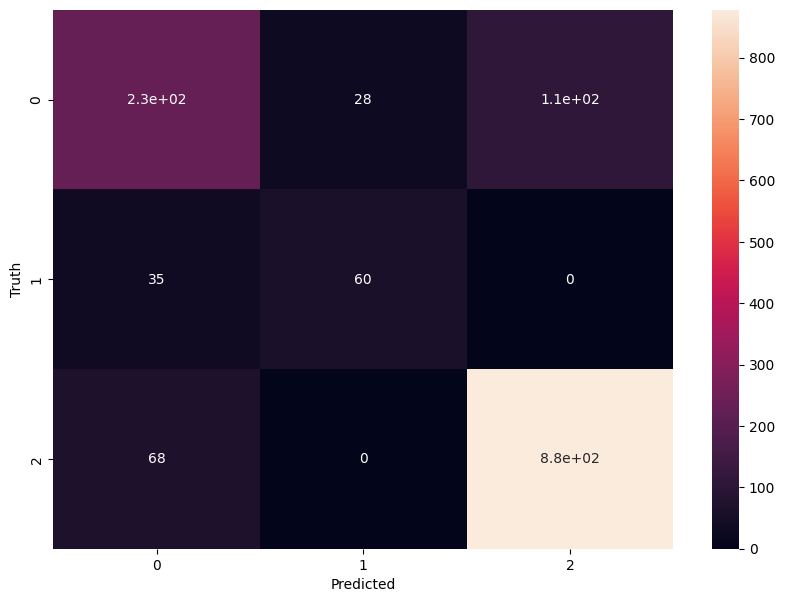

In [281]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Importing Classification Report

In [282]:
from sklearn.metrics import classification_report

In [283]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.69      0.63      0.66       368
           1       0.68      0.63      0.66        95
           2       0.89      0.93      0.91       946

    accuracy                           0.83      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.82      0.83      0.83      1409



In [284]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predicted)

0.830376153300213

# Save the model

In [285]:
reg.save_model("xgb_model.json")

## Model Selection Justification
After evaluating multiple models, **XGBoost (XGB_Classifier)** was selected as the final model for the following reasons:

1. **Performance**: It achieved the highest cross-validated accuracy (~82%) compared to Logistic Regression and Random Forest.
2. **Handling Non-linearity**: XGBoost effectively captures complex non-linear relationships between customer behaviors (e.g., tenure vs revenue) that simpler models like Logistic Regression might miss.
3. **Robustness**: Gradient Boosting is naturally resilient to outliers and works well even with imbalanced datasets by focusing on difficult-to-predict cases during training.
4. **Feature Importance**: It provides native metrics to rank features, which is critical for the business to understand *why* customers are churning.